# Project 1: Counting words in college subreddits

Due 9/16. Reminder that you are allowed to use any amount of AI assistance or outside resources with citation

## Part 1: word counting and bag of words

In [1]:
#install spacy in the current conda environment
!pip install spacy


In [2]:
!pip install matplotlib

In [3]:
#download a small language model to help with cleaning tasks
!python -m spacy download en_core_web_sm



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.1 MB/s eta 0:00:11
     - -------------------------------------- 0.5/12.8 MB 1.1 MB/s eta 0:00:11
     -- ------------------------------------ 0.8/12.8 MB 745.8 kB/s eta 0:00:17
     --- ----------------------------------- 1.0/12.8 MB 882.6 kB/s eta 0:00:14
     --- ----------------------------------- 1.0/12.8 MB 882.6 kB/s eta 0:00:14
     --- ----------------------------------- 1.3/12.8 MB 871.6 kB/s eta 0:00:14
     ---- ---------------------------------- 1.6/12.8 MB 892.3 kB/s eta 0:00:13
     ----- --------------------------------- 1.8/12.8 MB 883.1 kB/s eta 0:00:13
     ------ -------------------------------- 2.1/12.8 MB 931.9 kB/s eta 0:

In [4]:
#import required libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import spacy
language_model = spacy.load("en_core_web_sm")
import matplotlib.pyplot as plt

import numpy as np

### Problem 1 and example: common words in the Michigan subreddit

In [5]:
#read the data from a csv file in the folder
mich=pd.read_csv("umich.csv")

In [6]:
#jupyter will print a pretty representation of most python objects if you just put the name
#we can see that the full text of each reddit comment is provided in the "text" column
mich

,Unnamed: 0,date,post_votes,text,user,com_votes
0,0,2024-09-04 15:33:20,2,"Zingermans has a nice reuben, pretty pricey bu...",Suspicious-Bad703,2
1,1,2024-09-04 15:33:20,2,I really love Tomokun!,webstbre000,2
2,2,2024-09-04 15:33:20,2,The Seoul is pretty good I especially like the...,iaxlmao,1
3,3,2024-09-04 15:33:20,2,A lot of it depends on what type of food and w...,I-696,1
4,4,2024-09-04 14:32:17,1,You can book completely enclosed private study...,sneep_,2
...,...,...,...,...,...,...
8334,8334,2024-07-02 12:35:36,9,It isn’t a student org,Vibes_And_Smiles,1
8335,8335,2024-07-02 11:07:10,0,Life \r\nMatter \r\nLife's matter,tctu,8
8336,8336,2024-07-02 11:07:10,0,google,SUPERazkari,4
8337,8337,2024-07-02 11:07:10,0,That’s a hard question to answer for a set of ...,Own-Resident-3837,-1


In [7]:
#this is a function that does some light cleaning, by removing newline characters, converting to lowercase, and removing punctuation

def clean(text):
    #remove newline and space characters
    text = ' '.join(text.split())
    #convert the text to lowercase
    text = text.lower()
    #remove punctuation
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    return text

In [8]:
#pandas allows us to quickly apply this cleaning function to all rows in a column
mich['cleaned_text'] = mich['text'].apply(clean)

In [9]:
#we can see the first comment after cleaning vs before
mich["cleaned_text"][0]

'zingermans has a nice reuben pretty pricey but the sammies are pretty big'

In [10]:
mich["text"][0]

'Zingermans has a nice reuben, pretty pricey but the sammies are pretty big'

In [11]:
#create a bag of words representation with count vectorizer
vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(mich['cleaned_text'])

In [12]:
#this is a sparse matrix, which is a more efficient way to store a matrix with many zeros
#the matrix has 8339 rows (one for each comment) and 15289 columns (one for each unique word in the dataset)
bag_of_words

<8339x15289 sparse matrix of type '<class 'numpy.int64'>'
	with 221217 stored elements in Compressed Sparse Row format>

In [13]:
#create a dataframe from the sparse matrix
#this is a more human-readable way to view the data
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

,aa,aadl,aapd,aata,ab,abab,abandon,abandoned,abbreviation,abbreviations,...,zoned,zones,zoning,zoo,zoom,zoomer,zoomers,zuckerberg,𝓲𝓷𝓼𝓮𝓬𝓾𝓻𝓮,𝘢𝘩𝘦𝘮
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8337,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
#dataframes have a convenient method for summing the values in each column
#this will give us the number of times each word appears in the dataset
word_counts = bow_df.sum()
#we can sort the values to see the most common words
word_counts = word_counts.sort_values(ascending=False)

#notice that the top words are not very informative, as they are common words that appear in many contexts
#and bottom words include a lot of typos and other noise
word_counts

the            11306
to              8480
and             6921
you             6256
of              5028
               ...  
journals           1
journeywhen        1
jpg                1
js                 1
𝘢𝘩𝘦𝘮               1
Length: 15289, dtype: int64

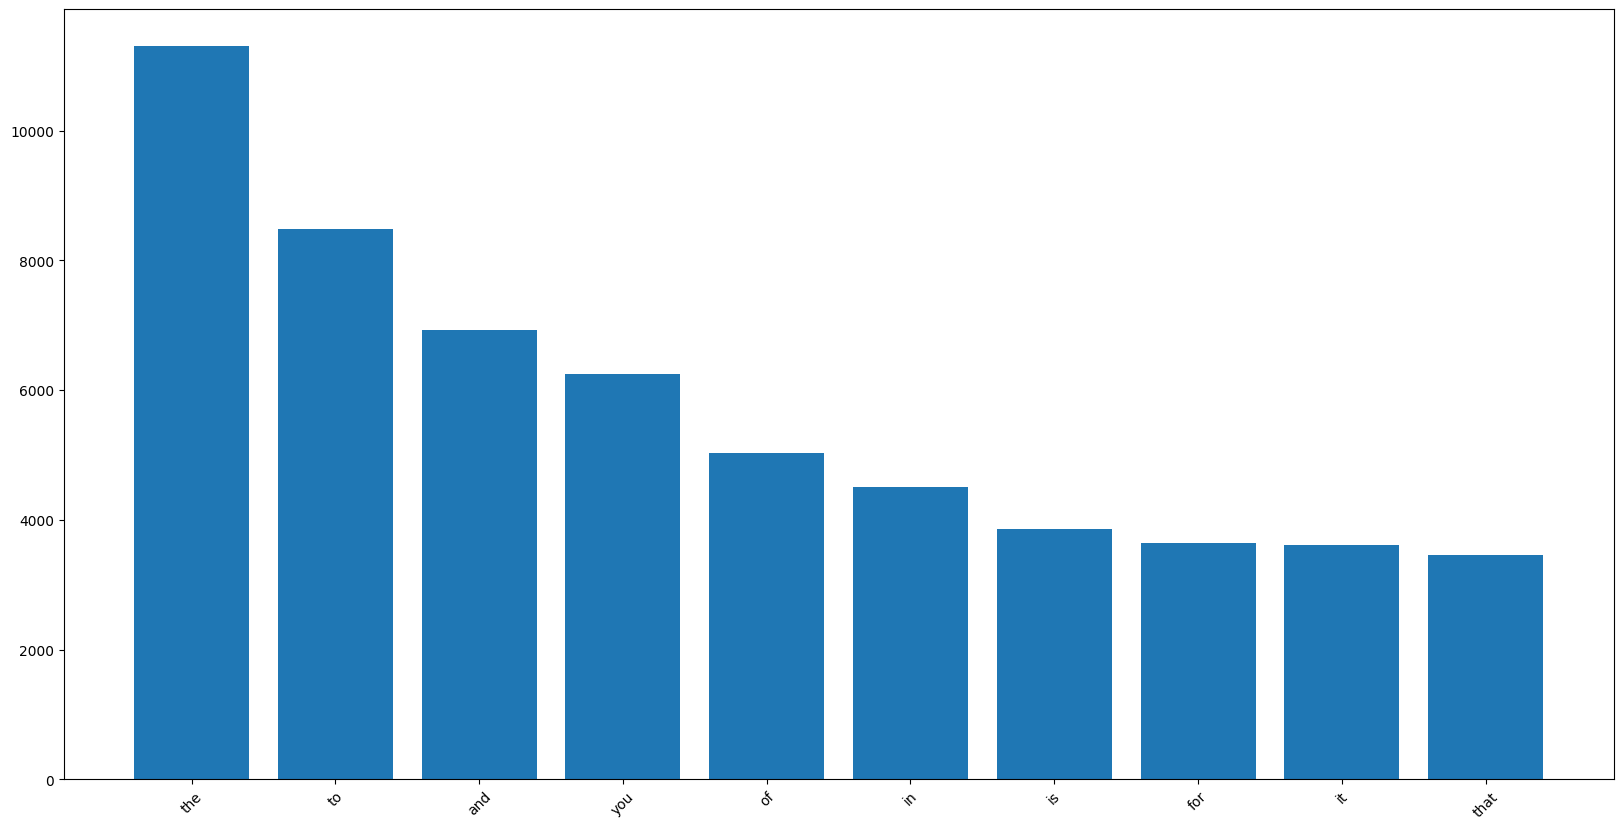

In [15]:
#we can plot the most common words
#we will only plot the top 10 words for readability
word_counts = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(word_counts.index, word_counts.values)
plt.xticks(rotation=45)
plt.show()

#### Question 1: what do you notice about the words in this plot? Is this useful for studying the community?

Answer here: This is similar to what was shown in the lecture where we talked about the BOW reading, the most common words in most instances of this will generally be the most common words in the english language, such as stopwords and other interjections we need for the things we say to be intelligeble to another human listener/reader. These are not useful for studying the community because this is very similar to what most corpuses would look like regardless of their individual set of documents given this set is simply common to the english language, we cannot derive any useful information about the community without first filtering through the stopwords and other such language that is exceedingly common in any set of english documents.

#### Lemmatization and stopword removal

In [16]:
#lemmatization function from the openclassrooms reading
def lemmatize(text):

   doc = language_model(text)

   tokens = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]

   return ' '.join(tokens)

In [17]:
#we can further process the text by removing stopwords and lemmatizing
mich['lemmatized_text'] = mich['cleaned_text'].apply(lemmatize)

In [18]:
#count vectorizer also has parameters min_df and max_df that can be used to filter out words that are too rare or too common
#min_df=3 means that a word must appear in at least 3 documents to be included, this will remove typos and rare words
#max_df=0.3 means that a word must appear in at most 30% of documents to be included, this will remove corpus-specific stopwords

#we are also able to include n-grams in the count vectorizer
#n-grams are sequences of n words that appear together in the text
#the n-gram_range parameter specifies the minimum and maximum n-gram size to include (so in this case, we are including both unigrams and bigrams)

vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
bag_of_words = vectorizer.fit_transform(mich['lemmatized_text'])

In [19]:
#we can see that we filtered out 11000 common words and typos
bag_of_words

<8339x8637 sparse matrix of type '<class 'numpy.int64'>'
	with 126833 stored elements in Compressed Sparse Row format>

In [20]:
#we can repeat the previous code to create a dataframe and count the words
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
word_counts = bow_df.sum()
word_counts = word_counts.sort_values(ascending=False)
word_counts

not               2862
student           1183
like              1183
people            1124
class              988
                  ... 
sell minnesota       3
cred                 3
credential           3
sell oregon          3
pay dollar           3
Length: 8637, dtype: int64

In [21]:
#we can convert this to a percentage instead of an absolute count by dividing by the total number of words
word_counts = word_counts / word_counts.sum()

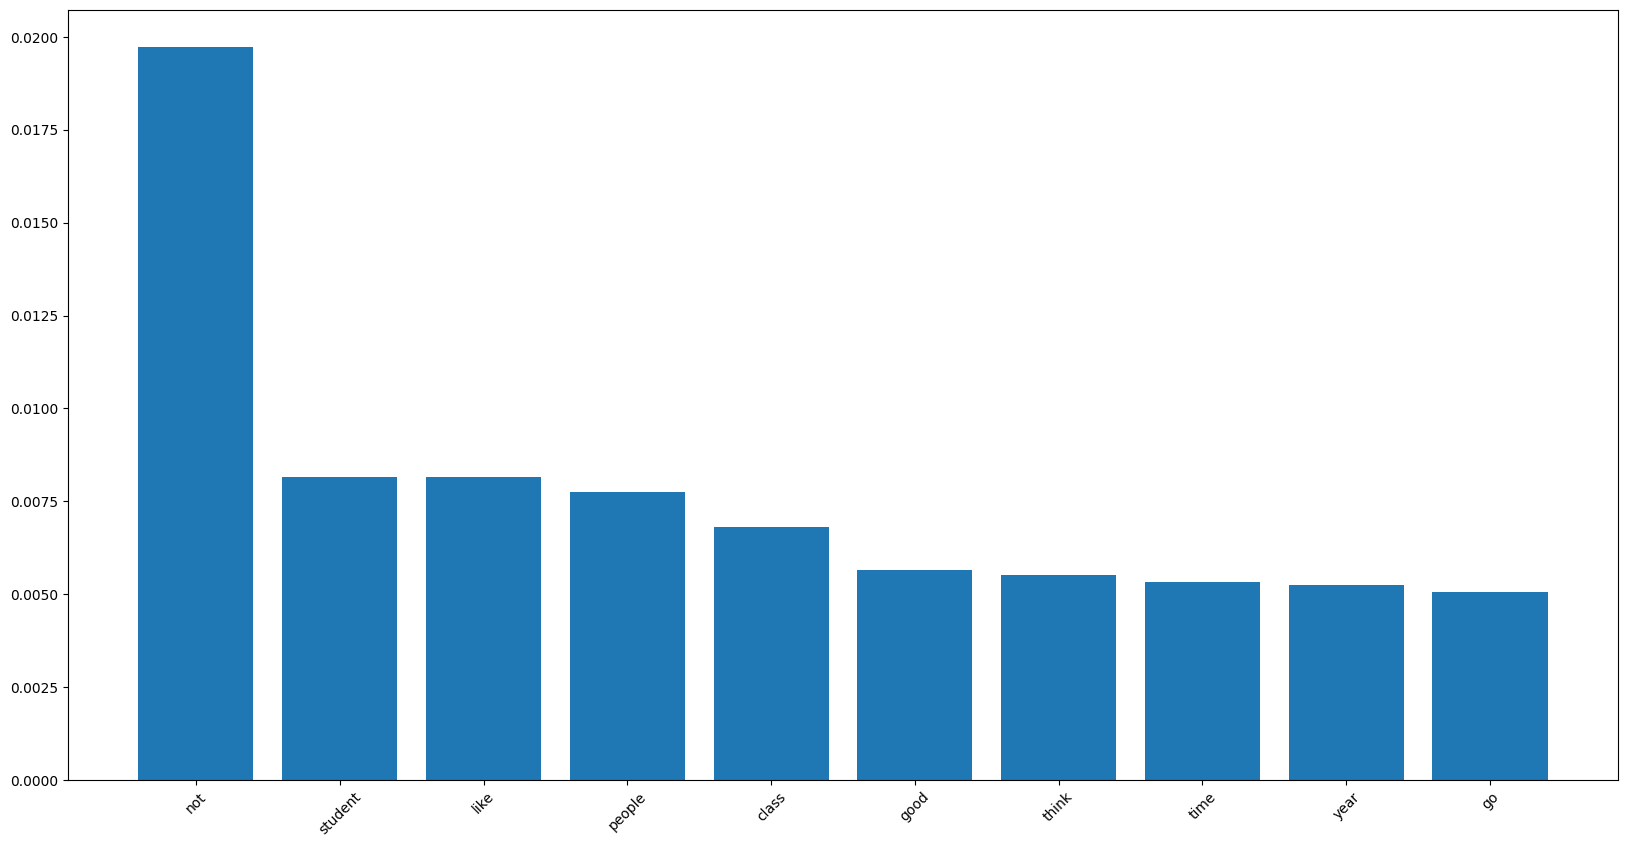

In [22]:
#we can plot the most common words
#we will only plot the top 10 words for readability
plot_list = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

In [23]:
#pandas allows us to access specific words in the series using the index
word_counts["student loan"]

4.138501862325838e-05

In [24]:
#we can also use a list of words to compare and plot specific words
plot_list=word_counts[["history", "business", "computer science", "cs", "computer"]]
plot_list

history             0.000352
business            0.000600
computer science    0.000034
cs                  0.001228
computer            0.000262
dtype: float64

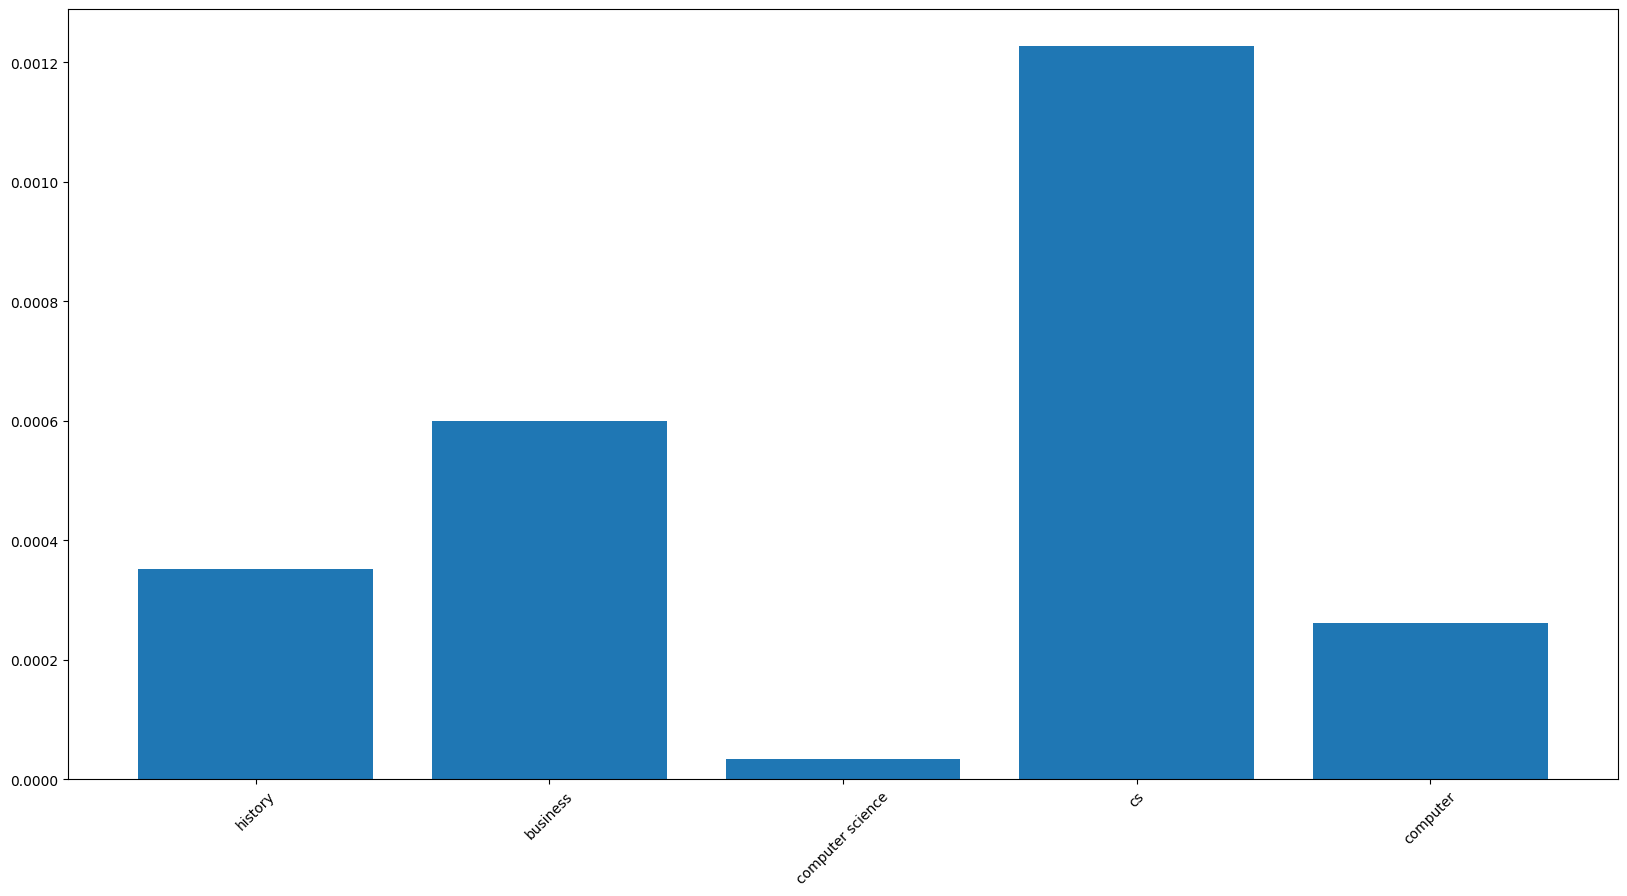

In [25]:
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

#### Question 2:

In [26]:
#TODO: pick 5 words that you find interesting or are curious about, and plot a bar plot of their frequency in this dataset 

In [27]:
plot_list2 = word_counts[['frat','engineering','business','gpa','football']]
plot_list2


frat           0.000221
engineering    0.000945
business       0.000600
gpa            0.000545
football       0.000276
dtype: float64

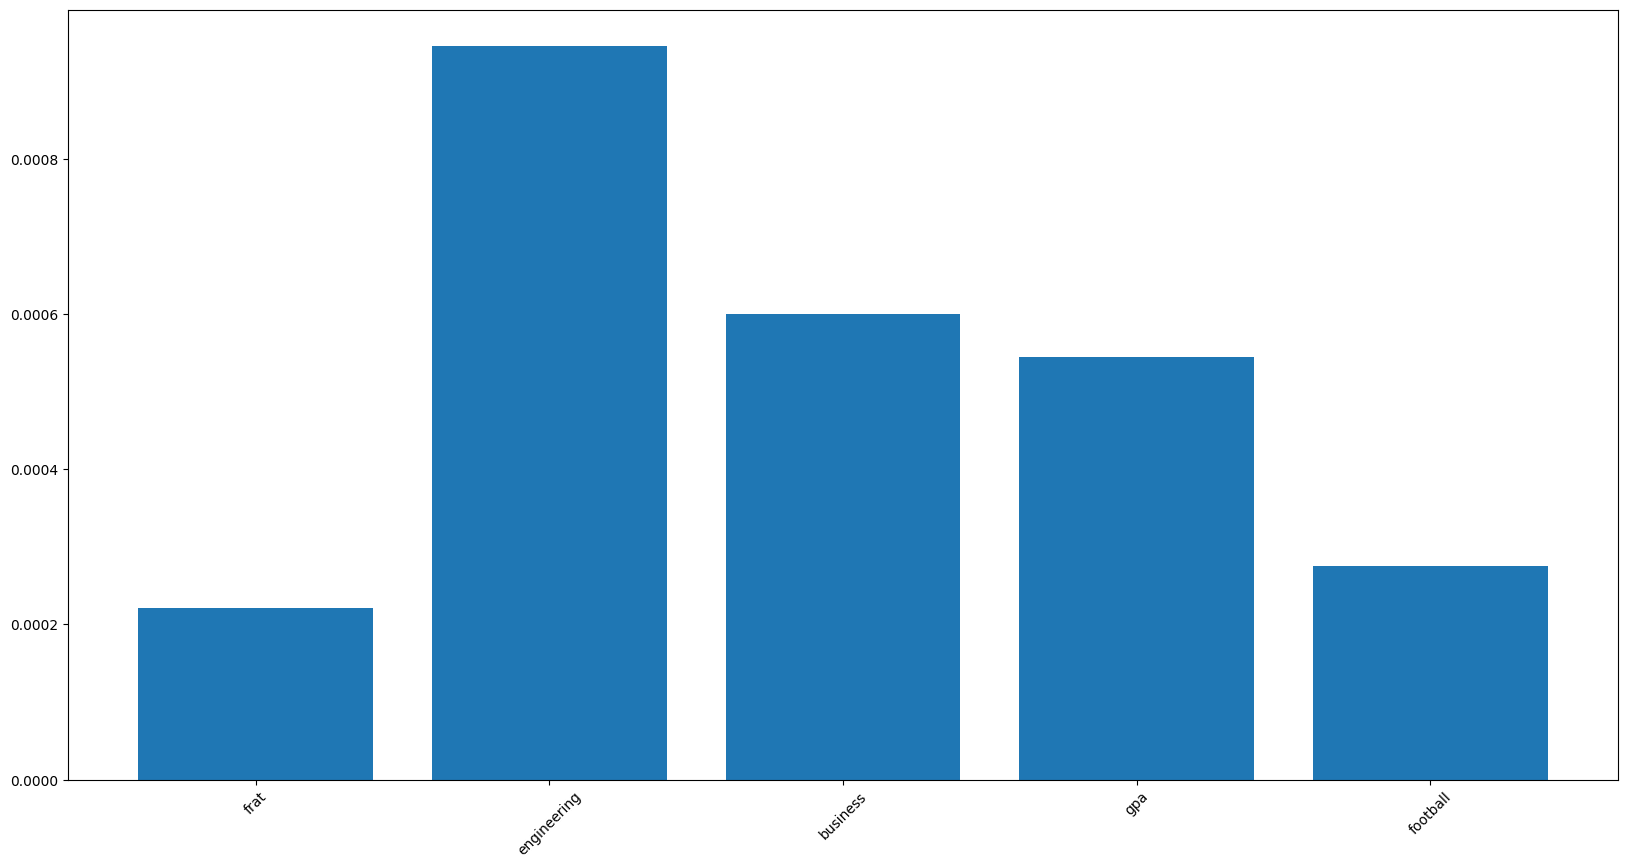

In [28]:
plt.figure(figsize=(20,10))
plt.bar(plot_list2.index, plot_list2.values)
plt.xticks(rotation=45)
plt.show()

### Problem 2: repeat this process with the Illinois subreddit data (in this directory as "uiuc.csv"). You should not have to change too much in the previous code besides the dataframe path and name. Your notebook should include the two bar graphs including and excluding stopwords. Use the same 5 words and compare their relative frequency between the two subreddits. Discuss any interesting differences you notice in a short markdown cell. 

In [29]:
uiuc=pd.read_csv("uiuc.csv")
uiuc

,Unnamed: 0,date,post_votes,text,user,com_votes
0,0,2024-09-04 14:43:40,2,Have the same professor! And in lecture he did...,zhen3441,2
1,1,2024-09-04 14:43:40,2,Do you find it helpful to still go to the lect...,Kai2747,1
2,2,2024-09-04 12:52:08,3,Have you tried emailing University Housing to ...,TurboBKTastic,2
3,3,2024-09-04 12:52:08,3,Purchasing Illini Cash should get you added to...,HoosierCAB,2
4,4,2024-09-04 12:52:08,3,"Just did, thanks for the suggestion! It hadn't...",Sector-Both,1
...,...,...,...,...,...,...
4720,4720,2024-08-21 20:28:40,1,Im interested if you're still looking,Accomplished_Fix2409,0
4721,4721,2024-08-21 20:26:15,7,I went to one of the taylor nights. was quite ...,student176895,4
4722,4722,2024-08-21 20:21:54,10,"Hey, I’m so sorry to hear that’s happening. If...",OCCLUIUC,5
4723,4723,2024-08-21 20:21:54,10,"AFAIK, the “cleaning company” that UGroup empl...",perpetuallytired29,3


In [30]:
uiuc['cleaned_text'] = uiuc['text'].apply(clean)

In [31]:
uiuc_vectorizer = CountVectorizer()
uiuc_bag_of_words = uiuc_vectorizer.fit_transform(uiuc['cleaned_text'])

In [32]:
uiuc_bow_df = pd.DataFrame(uiuc_bag_of_words.toarray(), columns=uiuc_vectorizer.get_feature_names_out())
uiuc_bow_df

,aa,aaa,aaaaah,aaabb,ab,abandoned,abcc,abide,abilities,ability,...,zombie,zone,zones,zoo,zoom,zoomed,봉사를,세계로,숭실,진리와
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4720,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4721,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4722,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4723,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
uiuc_word_counts = uiuc_bow_df.sum()
uiuc_word_counts = uiuc_word_counts.sort_values(ascending=False)
uiuc_word_counts

the                                                                                                       4613
to                                                                                                        3629
and                                                                                                       2973
you                                                                                                       2551
of                                                                                                        1854
                                                                                                          ... 
httpswwwwciacomnewsraresquirrelmemorializedonuoficampus                                                      1
httpswwwurbanaillinoisussitesdefaultfilesattachmentslandlordtenantpdf                                        1
httpswwwuoficreditunionorgcreditcreditcardshttpswwwuoficreditunionorgcreditcreditcards                       1
h

In [34]:
uiuc['lemmatized_text'] = uiuc['cleaned_text'].apply(lemmatize)

In [35]:
uiuc_vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
uiuc_bag_of_words = uiuc_vectorizer.fit_transform(uiuc['lemmatized_text'])

In [36]:
uiuc_bow_df = pd.DataFrame(uiuc_bag_of_words.toarray(), columns=uiuc_vectorizer.get_feature_names_out())
uiuc_word_counts = uiuc_bow_df.sum()
uiuc_word_counts = uiuc_word_counts.sort_values(ascending=False)
uiuc_word_counts

not               1205
like               534
people             481
good               388
time               376
                  ... 
not personally       3
not person           3
not park             3
not open             3
ab                   3
Length: 3891, dtype: int64

In [37]:
uiuc_word_counts = uiuc_word_counts / uiuc_word_counts.sum()

In [38]:
uiuc_plot_list = uiuc_word_counts[['frat','engineering','business','gpa','football']]
uiuc_plot_list

frat           0.000181
engineering    0.000706
business       0.000543
gpa            0.000344
football       0.000271
dtype: float64

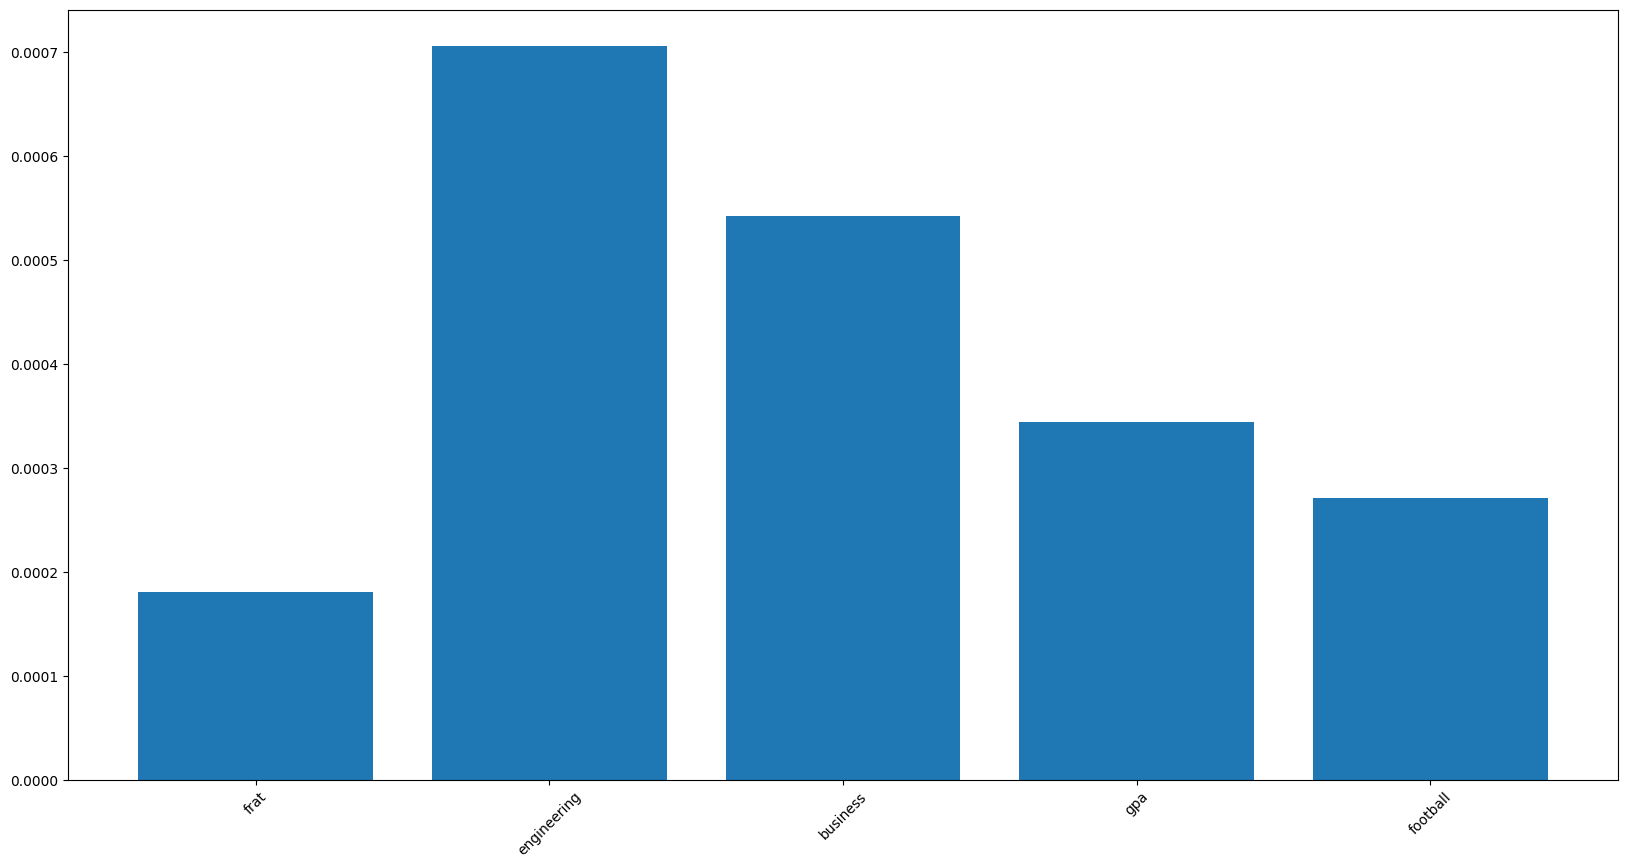

In [39]:
plt.figure(figsize=(20,10))
plt.bar(uiuc_plot_list.index, uiuc_plot_list.values)
plt.xticks(rotation=45)
plt.show()

The graphs are actually remarkably similar for the set of five words that I chose to look at, the rates that people at UMich and Illinois are talking about these subjects are almost indentical comparitavely for all five words, the only immediately apparent difference being illinois students use the term 'gpa' less. However this makes sense to be given the words I chose, both schools are known for having a huge greek life on campus and good engineering/business schools, however I am surprised to see that Michigan students don't talk about football more than UIUC students do given their programs history and recent success in comparison to ours.

### Problem 3: using the provided combined dataframe, train a logistic regression model using the sklearn Logistic Regression implementation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html. Create a bag of words table from the combined data, and use that along with the "label" column to train the classifier. Please try this out and be prepared with issues or questions next Monday. We will be discussing in class

In [40]:
uiuc=pd.read_csv("uiuc.csv")
mich=pd.read_csv("umich.csv")

#sample so we have even number of samples from each dataset
mich=mich.sample(n=4725)

#assign labels based on origin subreddit of comment
uiuc['label']=1
mich['label']=0

#you will be working with the data csv for the rest of the question
data=pd.concat([uiuc,mich])

In [41]:
#clean and lemmatize the data csv
data['cleaned_text'] = data['text'].apply(clean)
data['lemmatized_text'] = data['cleaned_text'].apply(lemmatize)
data

,Unnamed: 0,date,post_votes,text,user,com_votes,label,cleaned_text,lemmatized_text
0,0,2024-09-04 14:43:40,2,Have the same professor! And in lecture he did...,zhen3441,2,1,have the same professor and in lecture he did ...,professor lecture go to learn stuff ourself re...
1,1,2024-09-04 14:43:40,2,Do you find it helpful to still go to the lect...,Kai2747,1,1,do you find it helpful to still go to the lect...,find helpful lecture slide embed mistake make ...
2,2,2024-09-04 12:52:08,3,Have you tried emailing University Housing to ...,TurboBKTastic,2,1,have you tried emailing university housing to ...,try email university housing request access
3,3,2024-09-04 12:52:08,3,Purchasing Illini Cash should get you added to...,HoosierCAB,2,1,purchasing illini cash should get you added to...,purchase illini cash add nonresident meal plan...
4,4,2024-09-04 12:52:08,3,"Just did, thanks for the suggestion! It hadn't...",Sector-Both,1,1,just did thanks for the suggestion it hadnt oc...,thank suggestion not occur
...,...,...,...,...,...,...,...,...,...
2640,2640,2024-08-25 15:15:38,1,"30 minutes should be enough. and yes, it would...",Latter_Specific,3,0,minutes should be enough and yes it would be ...,minute yes good way
5361,5361,2024-07-30 20:53:58,233,i live in apartments nearby and have a ring do...,Odd-Relief323,9,0,i live in apartments nearby and have a ring do...,live apartment nearby ring doorbell alert vide...
6253,6253,2024-07-20 15:30:00,0,take physics 160/161 then,ExperimentalJunior,1,0,take physics then,physics
249,249,2024-09-03 19:03:18,79,I've linked the litany of sources below that h...,Able_Note_2628,1,0,ive linked the litany of sources below that ha...,ve link litany source report ask know will not...


In [42]:
#create a bag of words representation with count vectorizer
data_vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
data_bag_of_words = data_vectorizer.fit_transform(data['lemmatized_text'])
data_bag_of_words

<9450x8483 sparse matrix of type '<class 'numpy.int64'>'
	with 126241 stored elements in Compressed Sparse Row format>

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [44]:
#train a logistic regression model using the bag of words features as X and the label column as y
logistic_model = LogisticRegression()
logistic_model.fit(data_bag_of_words, data['label'])

LogisticRegression()

In [45]:
#report the accuracy of the model
logistic_model.score(data_bag_of_words, data['label'])

0.9058201058201059

#### Part 2: hold out part of the dataset using sklearn train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Pass in your previously generated bag of words as X and the label column as y. Use only the X_train and y_train for training and hold out the X_test and y_test to score the model on unseen data.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(data_bag_of_words, data['label'], test_size=0.2, random_state=103)

In [47]:
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [48]:
logistic_model.score(X_test, y_test)

0.7158730158730159

In [49]:
# what is the accuracy of the model? Is it better or worse than previous?Why do you think it has changed? 

The models accuracy is noticeably lower when not trained on the whole data set, this is because it has to predict things it has never seen before, models almost always perform worse on the test data when it is separated from the train data than if they are given the entire dataset and then asked to make predictions.

#### Part 3: Examine the top features of your model using the following code

In [50]:
#get the coefficients of the model and plot the top 10 most positive and top 10 most negative coefficients
#what do you notice about these words? Are they surprising or expected?


In [60]:
bow_df = pd.DataFrame(data_bag_of_words.toarray(), columns=data_vectorizer.get_feature_names_out())


In [63]:
coefficients = pd.DataFrame({'feature': bow_df.columns, 'coefficient': logistic_model.coef_[0]})
coefficients = coefficients.sort_values('coefficient', ascending=False)
top_10_positive = coefficients.head(10)
top_10_negative = coefficients.tail(10)

In [64]:
top_10_negative

,feature,coefficient
4355,mcard,-1.712585
7871,uofm,-1.750466
1965,eec,-1.773847
2572,fry,-1.790072
1709,diag,-1.803397
1482,csg,-1.863065
7782,umich,-2.082628
2528,fresno,-2.093861
7778,um,-2.098059
4435,michigan,-3.190364


In [65]:
top_10_positive

,feature,coefficient
7771,uiuc,2.509204
7882,urbana,2.084219
2906,grainger,1.951452
934,champaign,1.830145
6250,rsos,1.826657
3341,illini,1.763209
1535,danville,1.726313
3344,illinois,1.693685
7611,tow,1.561700
2943,green,1.517171


In [ ]:
#examine these words and see if they make sense. Do they differentiate UIUC from another university?

Yes, it is evident when looking at what words are classified as most positive and most negative that this dataset reflects more positively on UIUC than UMich, as most of the most positive words have to do with UIUC and the most negative have to do with Michigan, which makes sense in this context.

### Problem 4: Train a 10 topic topic model from the UIUC subreddit data using Gensim LDA. (https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html) If you get here before Wednesday 9/11, don't rush to finish, but feel free to continue ahead. We will go through this in class. Print out the top words in each topic, and read through the words for each topic to decide the theme of the topic: remember this is subjective and there are no right or wrong answers. Print out a few comments with high frequencies of each topic and analyze if your topic labels were representative. 

In [67]:
!pip install gensim

   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.0 MB ? eta -:--:--
    --------------------------------------- 0.5/24.0 MB 1.4 MB/s eta 0:00:17
   - -------------------------------------- 0.8/24.0 MB 1.2 MB/s eta 0:00:19
   - -------------------------------------- 1.0/24.0 MB 1.3 MB/s eta 0:00:18
   -- ------------------------------------- 1.3/24.0 MB 1.3 MB/s eta 0:00:18
   -- ------------------------------------- 1.6/24.0 MB 1.2 MB/s eta 0:00:19
   --- ------------------------------------ 1.8/24.0 MB 1.3 MB/s eta 0:00:18
   --- ------------------------------------ 2.1/24.0 MB 1.2 MB/s eta 0:00:18
   --- ------------------------------------ 2.1/24.0 MB 1.2 MB/s eta 0:00:18
   --- ------------------------------------ 2.4/24.0 MB 1.2 MB/s eta 0:00:19
   ---- ----------------------------------- 2.6/24.0 MB 1.1 MB/s eta 0:00:20
   ---- ----------------------------------- 2.6/24.0 MB 1.1 MB/s eta 0:00:20
   ---- -----

In [68]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.matutils import Sparse2Corpus

In [71]:
uiuc_bag_of_words    

<4725x3891 sparse matrix of type '<class 'numpy.int64'>'
	with 49429 stored elements in Compressed Sparse Row format>

In [72]:
corpus = Sparse2Corpus(uiuc_bag_of_words, documents_columns=False)

In [73]:
id2word = dict((v, k) for k, v in uiuc_vectorizer.vocabulary_.items())

In [74]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=10) 

In [76]:
lda_model.print_topics()

[(0,
  '0.023*"thank" + 0.011*"warning" + 0.009*"get" + 0.009*"lease" + 0.009*"not" + 0.008*"weather" + 0.008*"hall" + 0.007*"come" + 0.007*"time" + 0.007*"trust"'),
 (1,
  '0.017*"like" + 0.012*"find" + 0.012*"not" + 0.012*"look" + 0.011*"need" + 0.011*"class" + 0.010*"time" + 0.010*"student" + 0.009*"good" + 0.007*"know"'),
 (2,
  '0.057*"not" + 0.011*"people" + 0.010*"housing" + 0.010*"student" + 0.009*"know" + 0.008*"feel" + 0.008*"think" + 0.008*"thing" + 0.007*"class" + 0.007*"want"'),
 (3,
  '0.014*"class" + 0.013*"like" + 0.013*"post" + 0.010*"ill" + 0.009*"think" + 0.009*"review" + 0.008*"introvert" + 0.008*"day" + 0.008*"time" + 0.007*"campus"'),
 (4,
  '0.034*"friend" + 0.015*"year" + 0.013*"day" + 0.013*"people" + 0.013*"like" + 0.012*"feel" + 0.012*"weather" + 0.010*"quad" + 0.010*"club" + 0.010*"good"'),
 (5,
  '0.027*"not" + 0.021*"people" + 0.010*"friend" + 0.009*"feel" + 0.009*"pipe" + 0.009*"hard" + 0.008*"bike" + 0.008*"way" + 0.008*"time" + 0.007*"find"'),
 (6,
  '0

Based on examining the top words in each of the 10 topics here, it would appear as if the themes vary for each topic significantly, if I had to make a guess about each theme for its corresponding topic, they would be:

Topic #1: something about dorm/housing situations

#2: something about classrooms environments/interacting with other students

#3: complaints about classroom situations

#4: being secluded from class/what happens when you're sick

#5: quad day

#6: having a hard time finding friends

#7: general campus environment

#8: student government/ having a voice on campus

#9: tap water

#10: freshman year experiences

In [77]:
lda_model.get_document_topics(corpus[10])

[(0, 0.016669767),
 (1, 0.84995085),
 (2, 0.016676193),
 (3, 0.016670426),
 (4, 0.016670365),
 (5, 0.016674232),
 (6, 0.016671468),
 (7, 0.016672572),
 (8, 0.016672775),
 (9, 0.01667137)]

In [78]:
models = lda_model.get_document_topics(corpus, minimum_probability=0)

In [79]:
rows = []
for i in range(len(models)):
    row = []
    for m in models[i]:
        row.append(m[1])
    rows.append(row)

topic_df=pd.DataFrame(rows)

In [80]:
topic_df.sort_values(3, ascending=False)

,0,1,2,3,4,5,6,7,8,9
211,0.001926,0.001926,0.001925,0.982671,0.001925,0.001925,0.001925,0.001926,0.001925,0.001925
416,0.002001,0.002002,0.002002,0.981985,0.002002,0.002002,0.002002,0.002002,0.002002,0.002002
795,0.002328,0.002328,0.002328,0.979050,0.002328,0.002328,0.002328,0.002328,0.002328,0.002328
1808,0.003335,0.003336,0.003336,0.969981,0.003336,0.003335,0.003336,0.003335,0.003335,0.003335
896,0.003456,0.003457,0.003456,0.968889,0.003457,0.003456,0.003459,0.003457,0.003457,0.003456
...,...,...,...,...,...,...,...,...,...,...
1603,0.252171,0.048057,0.057870,0.000895,0.000895,0.000895,0.607738,0.000895,0.029689,0.000895
2599,0.000894,0.428654,0.091176,0.000894,0.056102,0.228925,0.087393,0.090100,0.000894,0.014969
1010,0.000856,0.000856,0.029756,0.000856,0.111880,0.740272,0.082210,0.031601,0.000856,0.000856
243,0.000677,0.029768,0.470709,0.000677,0.010512,0.000677,0.213411,0.161273,0.097308,0.014988


In [83]:
import textwrap

pd.set_option('display.max_colwidth', None)
toprint=uiuc["text"][2599]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)

A course's grade distribution, how much work is required, and how much students
learn are essentially independent variables. Any permutation is possible. There
are courses that don't teach much, don't expect much of students, but still make
sure to curve the course around a low median grade—maybe in hopes of appearing
like they are teaching something. There are also well-designed courses where
students are appropriately challenged and supported, and where grades reflect
what they learn, not adherence to some arbitrary distribution. (This is one of
the many reasons why using GPA distribution to determine whether a course is a
good one to take is so misguided.)    There are also courses at other
universities that operate under the (misguided) assumption that their job is to
weed out students. Unfortunately, those courses tend not to be very good at
actually teaching the material, and end up really only selecting for students
who already know it. This is something we try to be very carefu

Based my above predictions and the values for what topic this text fits most into, my prediction would have been that this text is mostly about classroom environments and interacting with other students in class, I was evidently not entirely correct about what this topic represented, however I was somewhat close as this text appears to be talking about classroom policy.

In [84]:
pd.set_option('display.max_colwidth', None)
toprint=uiuc["text"][416]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)

Hey! I understand why it would be a good idea to take this class next semester;
however, I don't have many options for classes to take this semester. I am a CS
+ Econ major. I am already taking an Econ class, a CS class, intro classes, and
general education classes. I have credits for Composition 1 and Calculus 1. I
don't want to take Calculus 2 as I will be taking the proficiency exam for it
next semester. Also, I am concerned that I will get too overloaded next semester
if I take CS 128, 173, and 361 along with 257. Do you have any suggestions for
any other classes that I can take? I have a relatively light workload this
semester.


I was off the mark here on this topic, which seems to be about prerequisites and course credit, whereas I thought it had to do with sick and late policy based on the top words here.

In [85]:
pd.set_option('display.max_colwidth', None)
toprint=uiuc["text"][1603]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)

Let's start with email. To email group to dispute security deposit, I recommend
emailing:  account.inquiries@ugroupcu.com  (Note: this email was working 1 year
ago and I'm really hoping it's still active)    The carpet cleaning is going to
be hard to get around. Unless you have a receipt for getting it professionally
cleaned or something. Lots of leases have some kind of clause about getting the
carpet professionally cleaned after a lease. You may want to check your lease
paperwork for anything like this.    The painting, you can dispute. Inform them
the you believe the walls were left with no damage beyond normal wear and tear,
and that you should not be held accountable to cover that cost.    You can
question the cleaning costs, and there's a decent chance to get a partial
refund. If you took pictures of your apartment as you left it, you've got more
leverage to work with.    Sadly, Ugroup does something like this with many
students in Champaign (Urbana has better tenant's rights). I

I would have assumed this text would be about the campus environment based on the top words on the topic it has the highest value for, however it appears to be about dorm/campus apartment living conditions, meaning my prediciton was wrong once again.